In [2]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [3]:
import os
import sys

sys.path.append("..")

import random

import numpy as np
import torch
import torch.distributions as TD 
import wandb
from tqdm import tqdm

from src.costs.lse import MLPLSECost
from src.costs.mlp_based import MLPCost, MLPL2Cost
from src.models.energy_based import EGEOT
from src.plotting.distributions import plot_swiss_roll
from src.plotting.parameters import plot_B_parameters
from src.potentials.mlp_based import MLPPotential
from src.samplers.energy_based.sample_buffer import SampleBufferEgEOT
from src.samplers.from_dataset import DatasetSampler
from src.samplers.primary import StandardNormalSampler, SwissRollSampler
from src.utils.discrete_ot import OTPlanSampler
from src.utils.paired import generate_paired_data, get_GT_points, get_paired_sampler
from src.utils.train import compute_loss, update_average

from configs.energy_based.cost import MLPCostConfig, MLPLSECostConfig, MLPL2CostConfig
from configs.energy_based.dataset import DatasetConfig, MiniBatchConfig
from configs.energy_based.model import EBMConfig
from configs.energy_based.optimizer import OptPairedConfig, OptUnpairedConfig
from configs.energy_based.potential import PotentialConfig
from configs.energy_based.sampling import LangevinConfig
from configs.energy_based.train import TrainConfig

In [4]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
print(device)
torch.set_default_device(device)
dtype = torch.float64
torch.torch.set_default_dtype(dtype)

torch.set_default_device(device)
dtype = torch.float64
torch.torch.set_default_dtype(dtype)

cuda:0


## 2. Config

In [8]:
Q_X_UNPAIRED_SAMPLES = 16000
R_Y_UNPAIRED_SAMPLES = 16000
P_XY_PAIRED_SAMPLES = 16000
LR_PAIRED = 5e-4
LR_UNPAIRED = 2e-4
SAMPLING_NUM_ITER = 100
MAX_STEPS = 3000
COST_FUNCTION = "MLP"
PAIRED_BATCH_SIZE = 1024
UNPAIRED_BATCH_SIZE = 1024

# TODO: add to config
BASIC_NOISE_VAR = 1.0
P_SAMPLE_BUFFER_REPLAY = 0.95
SAMPLE_BUFFER_SAMPLES = 10000

# For MLPCost
HIDDEN_LAYERS = [128, 128]

# For MLPPotential
POTENTIAL_HIDDEN_LAYERS = [256, 256, 256]

In [9]:
dataset_config = DatasetConfig(
    P_XY_paired=P_XY_PAIRED_SAMPLES, Q_X_unpaired=Q_X_UNPAIRED_SAMPLES, R_Y_unpaired=R_Y_UNPAIRED_SAMPLES
)
minibatch_config = MiniBatchConfig()

potential_config = PotentialConfig(hidden_layers=POTENTIAL_HIDDEN_LAYERS)
if COST_FUNCTION == "MLP":
    cost_config = MLPCostConfig(hidden_layers=HIDDEN_LAYERS)
else:
    raise ValueError(f"Unknown cost function: {COST_FUNCTION}!")
model_config = EBMConfig(sampling=LangevinConfig(num_iterations=SAMPLING_NUM_ITER))

opt_unpaired_config = OptUnpairedConfig(lr=LR_UNPAIRED)
opt_paired_config = OptPairedConfig(lr=LR_PAIRED)

train_config = TrainConfig(
    steps_to=MAX_STEPS, paired_batch_size=PAIRED_BATCH_SIZE, unpaired_batch_size=UNPAIRED_BATCH_SIZE
)

In [10]:
torch.manual_seed(train_config.seed)
np.random.seed(train_config.seed)
random.seed(train_config.seed)

## 3. Create data and samplers

In [11]:
X_sampler = StandardNormalSampler(dim=dataset_config.x_dim, device=device)
Y_sampler = SwissRollSampler(dim=dataset_config.y_dim, device=device, dtype=dtype)
otp_sampler = OTPlanSampler(**minibatch_config.model_dump())
data_dir = "checkpoints/Tensors"
file_postfix = f"{minibatch_config.cost_function}_{dataset_config.P_XY_paired}"

X_paired_train, Y_paired_train, X_paired_test, Y_paired_test = generate_paired_data(
    X_sampler, Y_sampler, otp_sampler, dataset_config.P_XY_paired, "./checkpoints/Tensors", file_postfix, device=device
)

pd_train_sampler = get_paired_sampler(
    X_paired_train, Y_paired_train, train_config.paired_batch_size, dataset_config.P_XY_paired, device
)

X_unpaired_test = X_sampler.sample(dataset_config.P_XY_paired)
Y_unpaired_test = Y_sampler.sample(dataset_config.P_XY_paired)

In [12]:
if dataset_config.Q_X_unpaired > 0:
    source_data = X_sampler.sample(dataset_config.Q_X_unpaired)
    usd_sampler = DatasetSampler(source_data, device=device) # usd - unpaired source data
else:
    usd_sampler = DatasetSampler(X_paired_train, device=device)

if dataset_config.R_Y_unpaired > 0:
    target_data = Y_sampler.sample(dataset_config.R_Y_unpaired)
    utd_sampler = DatasetSampler(target_data, device=device) # utd - unpaired target data
else:
    utd_sampler = DatasetSampler(Y_paired_train, device=device)

## 4. Model initialization

In [13]:
potential = MLPPotential(**potential_config.model_dump())
cost = MLPCost(**cost_config.model_dump())

In [14]:
basic_noise_gen = TD.Normal(torch.tensor([0.0, 0.0]).to(device), torch.tensor([1.0, 1.0]).to(device) * BASIC_NOISE_VAR)

sample_buffer_instance = SampleBufferEgEOT(
    basic_noise_gen, p=P_SAMPLE_BUFFER_REPLAY, max_samples=SAMPLE_BUFFER_SAMPLES, device=device
)

model = EGEOT(potential, cost, sample_buffer_instance, model_config)

# For EMA update
if train_config.ema_update:
    model_copy = EGEOT(potential, cost, sample_buffer_instance, model_config)

## 5. Optimizers initialization

In [15]:
D_opt_unpaired = torch.optim.Adam(model.potential.parameters(), **opt_unpaired_config.model_dump())

In [16]:
D_opt_paired = torch.optim.Adam(model.cost.parameters(), **opt_paired_config.model_dump())

In [17]:
EXP_META_INFO = ""
EXP_NAME = (
    "EgEOT_Swiss_Roll_"
    + f"COST_FUNCTION_{COST_FUNCTION}_"
    + f"P_XY_PAIRED_{dataset_config.P_XY_paired}_"
    + f"Q_X_UNPAIRED_{dataset_config.Q_X_unpaired}_"
    + f"R_Y_UNPAIRED_{dataset_config.R_Y_unpaired}_"
    + f"LR_PAIRED_{opt_paired_config.lr}_"
    + f"LR_UNPAIRED_{opt_unpaired_config.lr}_"
    + f"MINIBATCH_COST_{minibatch_config.cost_function}_"
    + f"SAMPLING_STEPS_{model_config.sampling.num_iterations}_"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    COST_FUNCTION=COST_FUNCTION,
    X_DIM=dataset_config.x_dim,
    Y_DIM=dataset_config.y_dim,
    D_LR_PAIRED=opt_paired_config.lr,
    D_LR_UNPAIRED=opt_unpaired_config.lr,
    BATCH_SIZE=train_config.unpaired_batch_size,
    P_XY_PAIRED_SAMPLES=dataset_config.P_XY_paired,
    Q_X_UNPAIRED_SAMPLES=dataset_config.Q_X_unpaired,
    R_Y_UNPAIRED_SAMPLES=dataset_config.R_Y_unpaired,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH, exist_ok=True)

In [18]:
if train_config.steps_from > 0:
    D_opt_unpaired.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_unpaired_{train_config.steps_from}.pt")))
    D_opt_paired.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_paired_{train_config.steps_from}.pt")))

## 6. Model training

In [19]:
starting_points = torch.tensor([[-2.0, 0.0], [2.0, 2.0], [-0.0, -0.0]]) # torch.tensor([[-2.0, 0.0], [0.0, 0.0], [0.0, -2.0]])
num_ending_points = 64
num_starting_points_paired = 5
indices = random.choices(range(dataset_config.P_XY_paired), k=num_starting_points_paired)
starting_points_paired = X_paired_train[indices]
ending_points_paired = Y_paired_train[indices]

In [20]:
gt_Y_points = get_GT_points(X_sampler, Y_sampler, otp_sampler, starting_points)

 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                   | 43/64 [00:01<00:00, 40.49it/s]/trinity/home/m.persiyanov/miniconda3/envs/light-gcot/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:531: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:01<00:00, 40.50it/s]


  0%|                                                                                                                                                                     | 0/3000 [00:00<?, ?it/s]/trinity/home/m.persiyanov/miniconda3/envs/light-gcot/lib/python3.12/site-packages/torch/autograd/graph.py:744: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/pytorch_1716905969118/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Saved ../plots/16kpointsEBM_0/source_target.png
Saved ../plots/16kpointsEBM_0/paired_data.png
Saved ../plots/16kpointsEBM_0/gt_mapping.png
Saved ../plots/16kpointsEBM_0/Light-IOT_EBM.png


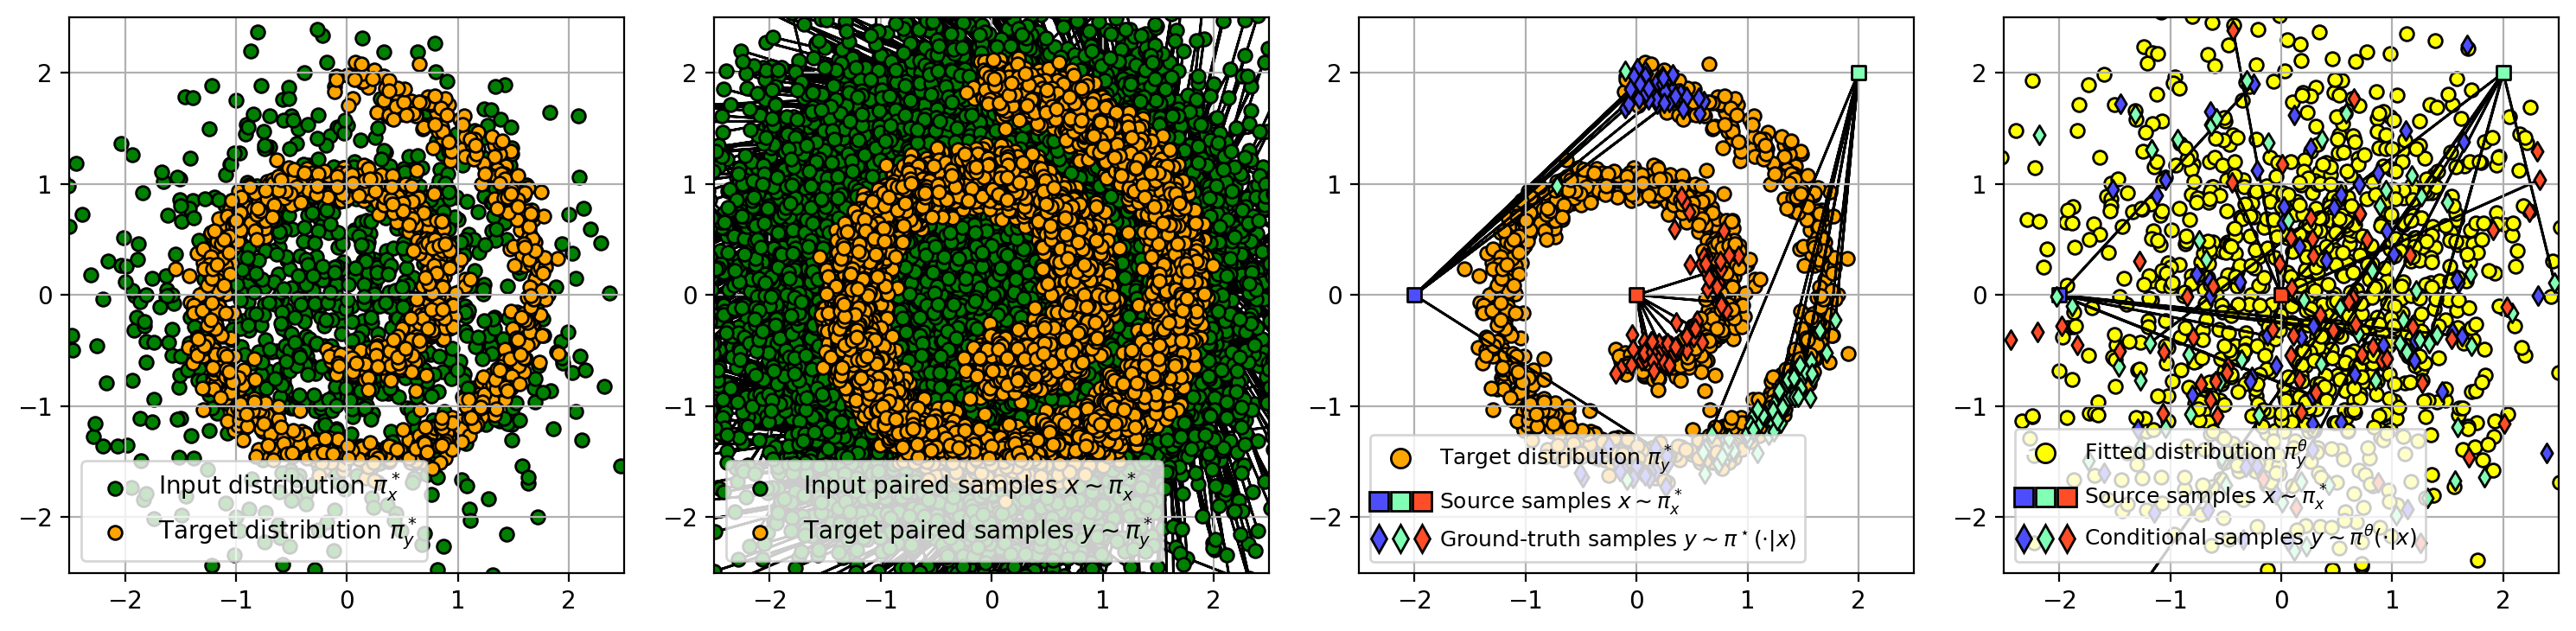

  3%|█████▏                                                                                                                                                     | 100/3000 [01:25<23:47,  2.03it/s]

Saved ../plots/16kpointsEBM_100/source_target.png
Saved ../plots/16kpointsEBM_100/paired_data.png
Saved ../plots/16kpointsEBM_100/gt_mapping.png
Saved ../plots/16kpointsEBM_100/Light-IOT_EBM.png


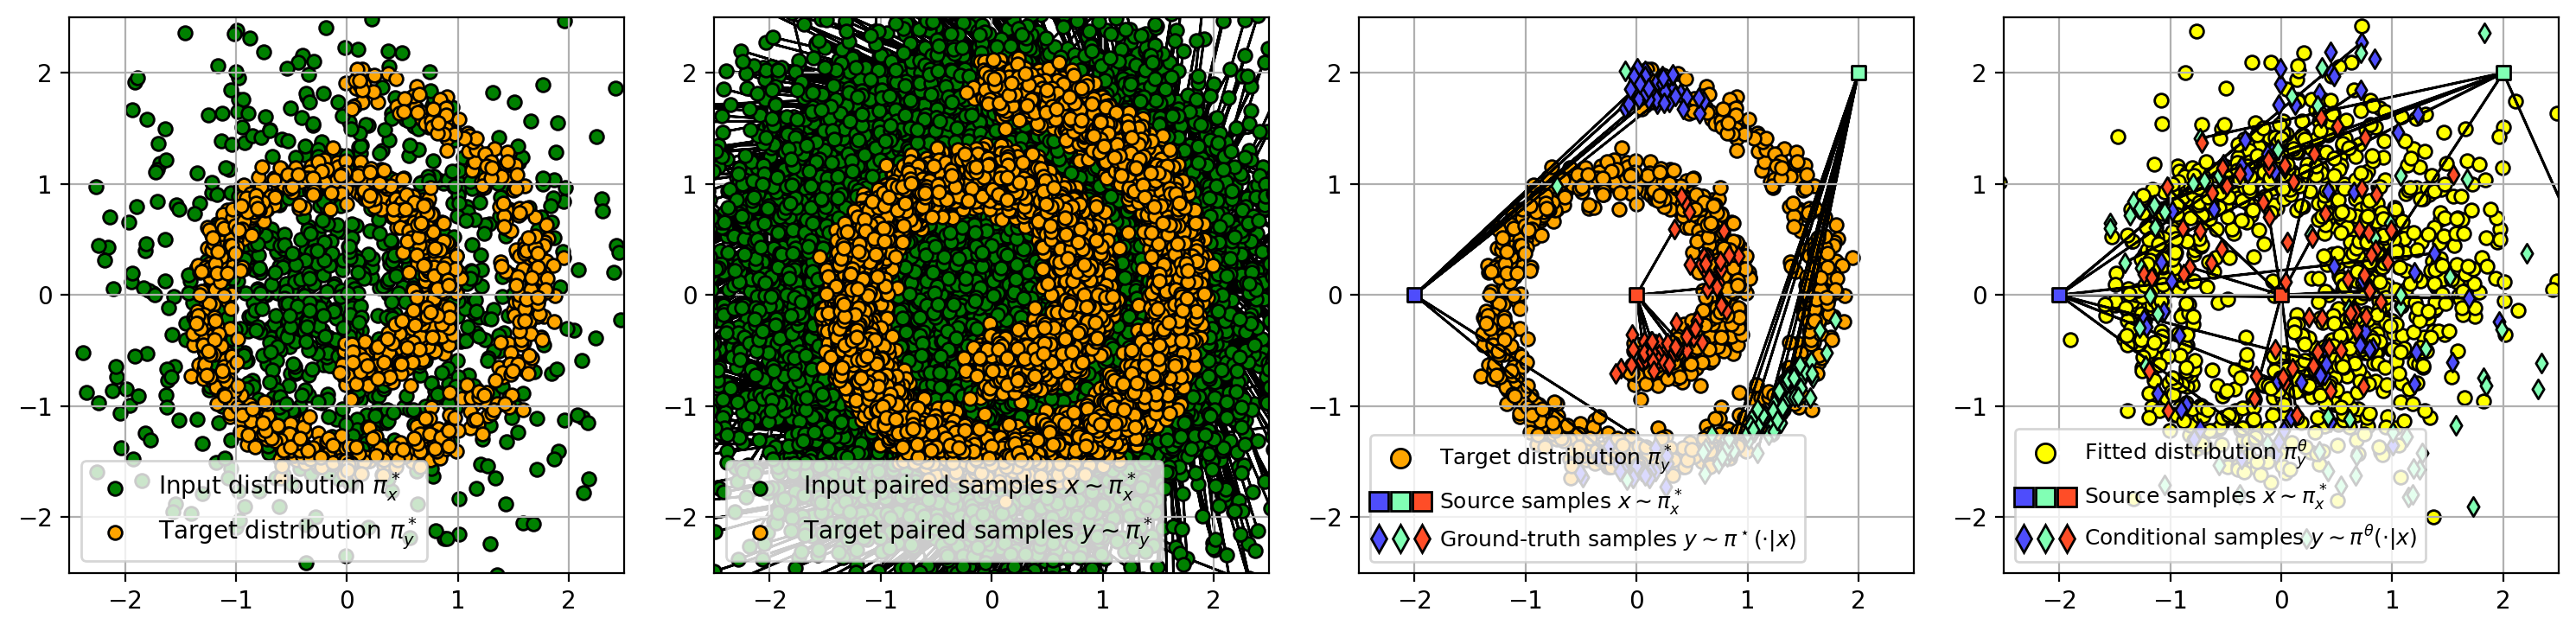

  7%|██████████▎                                                                                                                                                | 200/3000 [02:51<23:15,  2.01it/s]

Saved ../plots/16kpointsEBM_200/source_target.png
Saved ../plots/16kpointsEBM_200/paired_data.png
Saved ../plots/16kpointsEBM_200/gt_mapping.png
Saved ../plots/16kpointsEBM_200/Light-IOT_EBM.png


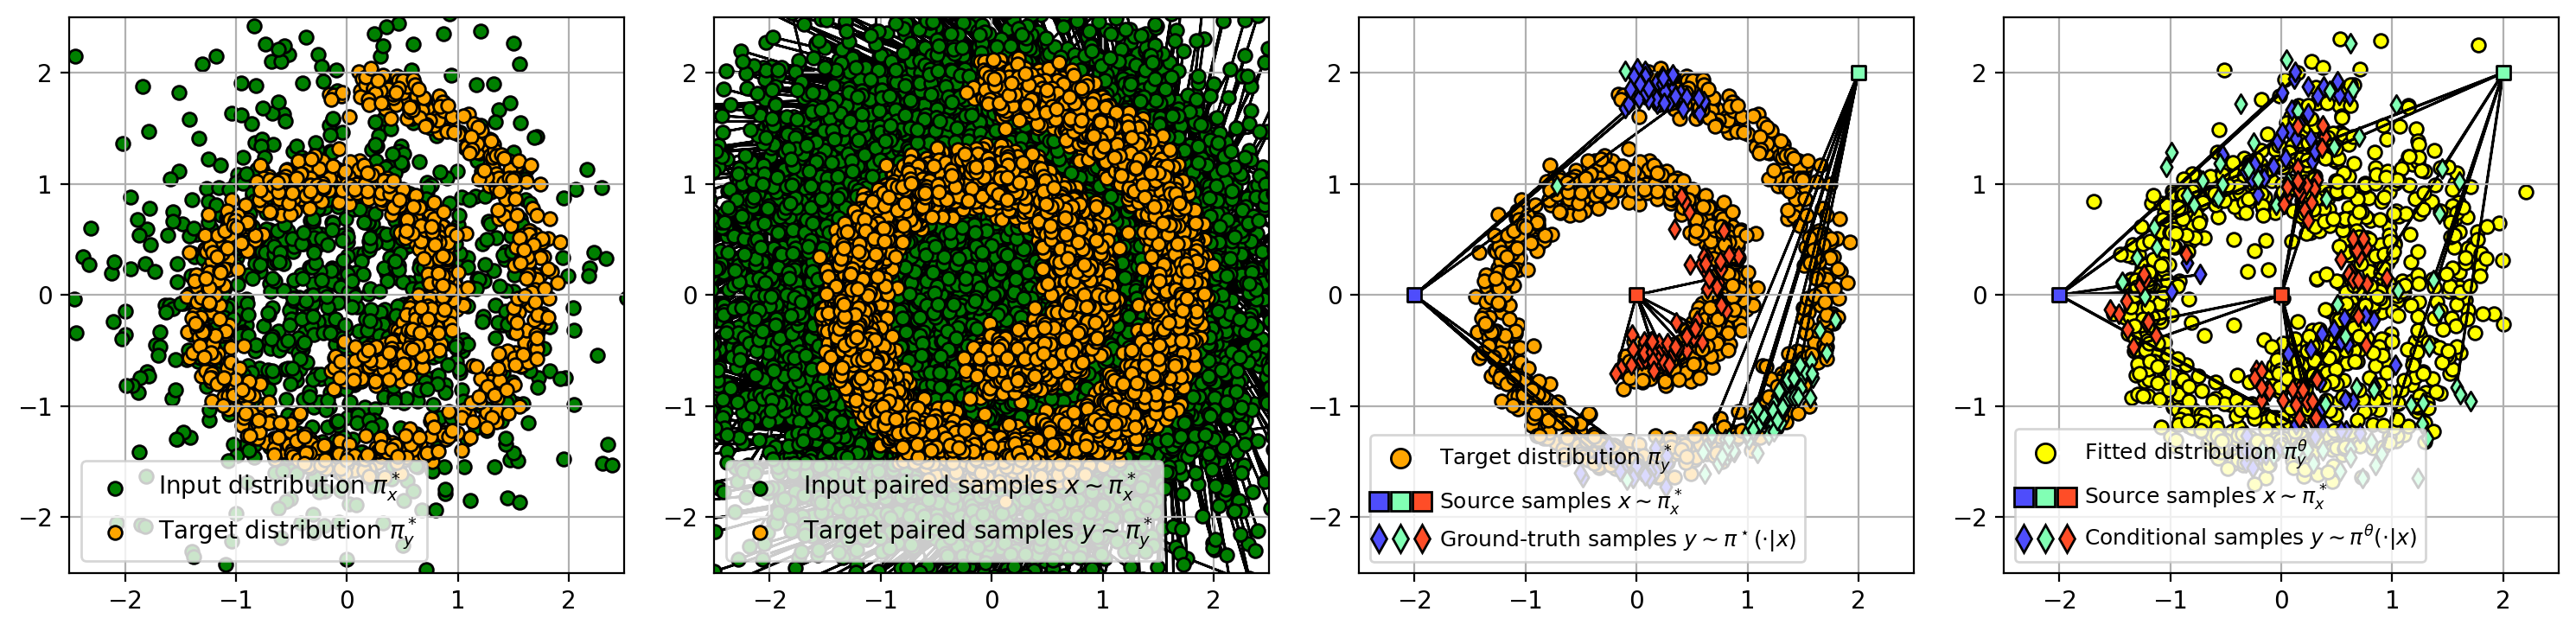

 10%|███████████████▌                                                                                                                                           | 300/3000 [04:18<22:33,  2.00it/s]

Saved ../plots/16kpointsEBM_300/source_target.png
Saved ../plots/16kpointsEBM_300/paired_data.png
Saved ../plots/16kpointsEBM_300/gt_mapping.png
Saved ../plots/16kpointsEBM_300/Light-IOT_EBM.png


In [ ]:
for step in tqdm(range(0, MAX_STEPS)):
    D_opt_unpaired.zero_grad()

    X = usd_sampler.sample(train_config.unpaired_batch_size)
    Y = utd_sampler.sample(train_config.unpaired_batch_size)

    output_unpaired = model.compute_unpaired_loss(X, Y, compute_stats=True)
    D_loss_unpaired = output_unpaired["loss"]

    D_opt_paired.zero_grad()
    X_paired, Y_paired = pd_train_sampler.sample(train_config.paired_batch_size)

    output_paired = model.compute_paired_loss(X_paired, Y_paired, compute_stats=True)
    D_loss_paired = output_paired["loss"]

    D_loss = D_loss_unpaired + D_loss_paired
    D_loss.backward()
    D_opt_paired.step()
    D_opt_unpaired.step()

    if train_config.ema_update:
        update_average(model_copy, model, 0.99)
        model = model_copy
    else:
        model = model

    if step % 100 == 0:
        plot = plot_swiss_roll(
            {"EBM": model},
            X_sampler,
            Y_sampler,
            X_paired_train,
            Y_paired_train,
            starting_points,
            gt_Y_points,
            save_dir = f'../plots/16kpointsEBM_{step}'
        ) 